# Notebook 3 — Méthodes de sélection de variables

**Projet CEA-LIST × CentraleSupélec — 2025-2026**

Ce notebook implémente et explique **5 méthodes de sélection de variables non supervisées**, organisées en deux familles :

**Famille A — Méthodes spectrales** (basées sur le graphe de voisinage)
- Laplacian Score (He et al., 2005)
- SPEC — Spectral Feature Selection (Zhao & Liu, 2007)
- MCFS — Multi-Cluster Feature Selection (Cai et al., 2010)

**Famille B — Méthodes à poids de variables** (basées sur K-Means)
- Sparse K-Means (Witten & Tibshirani, 2010)
- FWKM — Feature Weighted K-Means (Modha & Spangler, 2003)

---

## Fil rouge pédagogique

Pour expliquer chaque méthode, on utilise **deux jeux de données** :
1. **5 points A-E** pour les schémas pédagogiques (calculs à la main)
2. **300 points avec 10 variables** (2 signal + 8 bruit) pour les résultats

## 0. Imports et données de démonstration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform, pdist
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso
import os

os.makedirs('figures', exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

# Couleurs standardes
C_SIGNAL = '#1D9E75'
C_NOISE  = '#D85A30'
C_STRUCT = '#378ADD'
C_V      = '#534AB7'

In [2]:
# ─── Jeu pédagogique : 5 points A-E ─────────────────────────
pts5_xy = np.array([
    [1.0, 3.0],   # A
    [2.2, 3.2],   # B
    [1.5, 1.8],   # C
    [7.0, 1.8],   # D
    [7.8, 3.0],   # E
])
labels5 = ['A', 'B', 'C', 'D', 'E']

# Valeurs de 2 variables sur les 5 points (pour illustrer)
x1_signal = np.array([1.0, 1.2, 1.1, 5.0, 4.8])  # signal : {A,B,C}≈1, {D,E}≈5
x2_noise  = np.array([-0.5, 2.1, 0.3, -1.2, 1.8])  # bruit : aléatoire

# ─── Jeu réel : 300 points, 10 variables (2 signal + 8 bruit) ──
def build_signal_noise(n=300, k=3, d_signal=2, d_noise=8, seed=42):
    rng = np.random.default_rng(seed)
    centers = np.array([[0, 0], [4, 4], [0, 8]])
    per_c = n // k
    X_s = np.vstack([rng.normal(centers[i], 0.6, (per_c, d_signal)) for i in range(k)])
    y = np.concatenate([[i]*per_c for i in range(k)])
    X_n = rng.standard_normal((len(X_s), d_noise))
    X = StandardScaler().fit_transform(np.hstack([X_s, X_n]))
    return X, y

X300, y300 = build_signal_noise()
feat_names = [f'x{i+1}' for i in range(10)]
print(f'X300: {X300.shape}, y300: {y300.shape}')

X300: (300, 10), y300: (300,)


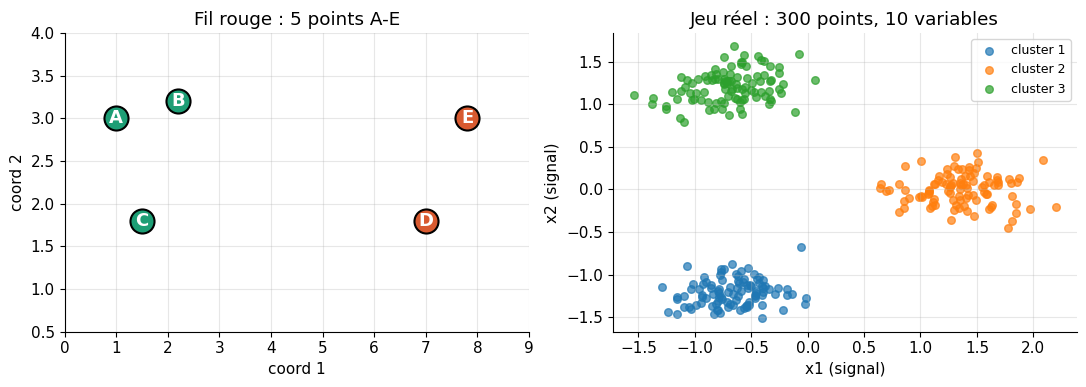

In [3]:
# Visualisation des deux jeux
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors5 = [C_SIGNAL]*3 + [C_NOISE]*2

ax = axes[0]
for i, (p, lab) in enumerate(zip(pts5_xy, labels5)):
    ax.scatter(*p, s=300, c=colors5[i], edgecolor='black', linewidth=1.5, zorder=3)
    ax.annotate(lab, p, ha='center', va='center', fontsize=13, fontweight='bold', color='white', zorder=4)
ax.set_xlim(0, 9); ax.set_ylim(0.5, 4.0)
ax.set_title('Fil rouge : 5 points A-E')
ax.set_xlabel('coord 1'); ax.set_ylabel('coord 2')
ax.grid(alpha=0.3)

ax = axes[1]
for c in range(3):
    mask = y300 == c
    ax.scatter(X300[mask, 0], X300[mask, 1], s=30, alpha=0.7, label=f'cluster {c+1}')
ax.set_title('Jeu réel : 300 points, 10 variables')
ax.set_xlabel('x1 (signal)'); ax.set_ylabel('x2 (signal)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

# FAMILLE A — Méthodes spectrales

Les 3 méthodes LS, SPEC et MCFS partagent le même **outil de base** : un graphe de voisinage et son Laplacien.

## A.0 L'outil commun : graphe et Laplacien

**Principe** : on construit un graphe où chaque point est relié à ses voisins proches, et on analyse ce graphe.

- Matrice **S** (n×n) : qui est voisin de qui (grand = proches, 0 = pas voisins)
- Vecteur **D** (n) : D_i = somme de la ligne i de S ("connectivité" du point i)

In [4]:
# ─── Construction de S et D sur les 5 points ────────────────
D_dist = squareform(pdist(pts5_xy))
t_param = np.median(D_dist[D_dist > 0])**2
S_full = np.exp(-D_dist**2 / t_param)
np.fill_diagonal(S_full, 0)

# Epsilon-graph (seuil de distance) pour lisibilité pédagogique
eps = 6.5
S = np.zeros_like(S_full)
for i in range(5):
    for j in range(5):
        if i != j and D_dist[i, j] < eps:
            S[i, j] = S_full[i, j]

D_deg = S.sum(axis=1)
print(f'S =\n{np.round(S, 2)}')
print(f'D = {np.round(D_deg, 2)}')

S =
[[0.   0.95 0.94 0.26 0.  ]
 [0.95 0.   0.91 0.4  0.32]
 [0.94 0.91 0.   0.33 0.22]
 [0.26 0.4  0.33 0.   0.93]
 [0.   0.32 0.22 0.93 0.  ]]
D = [2.15 2.59 2.41 1.92 1.47]


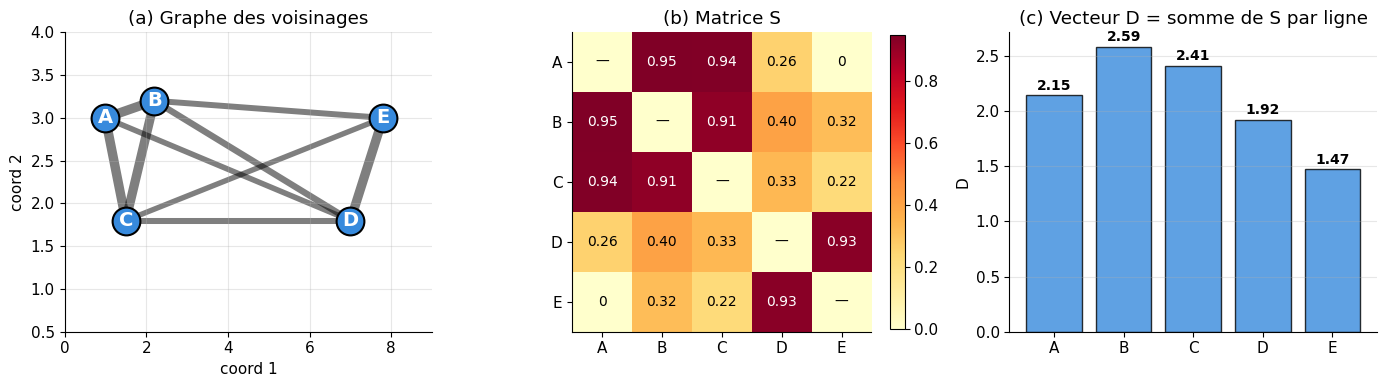

In [5]:
# Figure F2 : graphe + S + D
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
for i in range(5):
    for j in range(i+1, 5):
        if S[i, j] > 0:
            ax.plot([pts5_xy[i,0], pts5_xy[j,0]], [pts5_xy[i,1], pts5_xy[j,1]],
                    'k-', alpha=0.5, linewidth=3 + S[i,j]*4, zorder=1)
for i, (p, lab) in enumerate(zip(pts5_xy, labels5)):
    ax.scatter(*p, s=400, c=C_STRUCT, edgecolor='black', linewidth=1.5, zorder=3)
    ax.annotate(lab, p, ha='center', va='center', fontsize=14, fontweight='bold', color='white', zorder=4)
ax.set_xlim(0, 9); ax.set_ylim(0.5, 4.0)
ax.set_title('(a) Graphe des voisinages')
ax.set_xlabel('coord 1'); ax.set_ylabel('coord 2')
ax.grid(alpha=0.3)

ax = axes[1]
im = ax.imshow(S, cmap='YlOrRd', vmin=0, vmax=S.max())
for i in range(5):
    for j in range(5):
        val = S[i, j]
        color = 'black' if val < S.max()*0.5 else 'white'
        txt = '—' if i == j else f'{val:.2f}' if val > 0 else '0'
        ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=10)
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels(labels5); ax.set_yticklabels(labels5)
ax.set_title('(b) Matrice S')
plt.colorbar(im, ax=ax, fraction=0.04)

ax = axes[2]
bars = ax.bar(labels5, D_deg, color=C_STRUCT, alpha=0.8, edgecolor='black')
for b, v in zip(bars, D_deg):
    ax.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('(c) Vecteur D = somme de S par ligne')
ax.set_ylabel('D'); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.savefig('figures/F2_graph_S_D.png', dpi=120, bbox_inches='tight'); plt.show()

## A.1 Laplacian Score (He et al., 2005)

**Type.** Méthode *filter*. Score calculé variable par variable, sans clustering.

**Question.** *Pour une variable donnée, est-ce que les points voisins ont des valeurs proches ?*

- **OUI** → variable lisse sur le graphe → **informative** → score bas
- **NON** → la variable saute entre voisins → **bruit** → score haut

**Formule.**

$$\text{LS}_j = \frac{\sum_{i,k} S_{ik}\,(f_{ji} - f_{jk})^2}{\sum_i D_{ii}\,(f_{ji} - \bar{f}_j)^2}$$

- **Numérateur** = "sauts entre voisins" pondérés par la proximité S
- **Dénominateur** = variance totale de la variable (pour normaliser)

In [6]:
def laplacian_score(f, S):
    '''Laplacian Score pour un vecteur f avec matrice de similarité S.'''
    d = S.sum(axis=1)
    D_mat = np.diag(d)
    f_tilde = f - (f @ d) / d.sum()
    L = D_mat - S
    num = f_tilde @ L @ f_tilde
    den = f_tilde @ D_mat @ f_tilde
    return num / den if den > 0 else np.inf

LS_x1 = laplacian_score(x1_signal, S)
LS_x2 = laplacian_score(x2_noise, S)
print(f'LS(x1 signal) = {LS_x1:.3f}')
print(f'LS(x2 bruit)  = {LS_x2:.3f}')
print(f'→ x1 a un score {LS_x2/LS_x1:.1f}x plus petit que x2 — signal bien détecté')

LS(x1 signal) = 0.668
LS(x2 bruit)  = 1.427
→ x1 a un score 2.1x plus petit que x2 — signal bien détecté


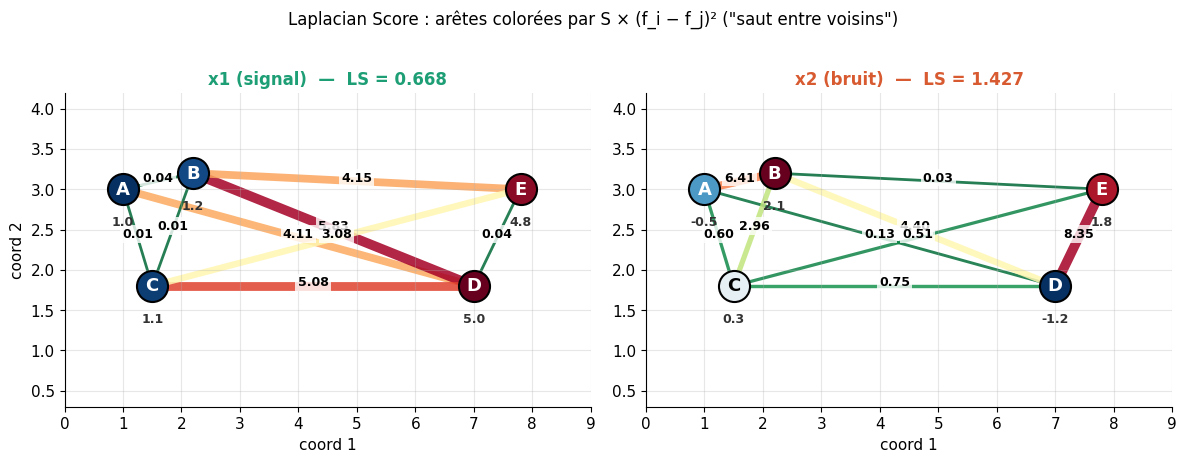

In [7]:
# Figure F3 : arêtes colorées par saut
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax_idx, (f_vec, name, ls_val, col) in enumerate([
    (x1_signal, 'x1 (signal)', LS_x1, C_SIGNAL),
    (x2_noise,  'x2 (bruit)',  LS_x2, C_NOISE)
]):
    ax = axes[ax_idx]
    edges_info = []
    for i in range(5):
        for j in range(i+1, 5):
            if S[i, j] > 0:
                contrib = S[i, j] * (f_vec[i] - f_vec[j])**2
                edges_info.append((i, j, contrib))
    max_contrib = max(e[2] for e in edges_info)
    
    for i, j, contrib in edges_info:
        ratio = contrib / max_contrib if max_contrib > 0 else 0
        color_val = plt.cm.RdYlGn_r(ratio)
        width = 2 + 5 * ratio
        ax.plot([pts5_xy[i,0], pts5_xy[j,0]], [pts5_xy[i,1], pts5_xy[j,1]],
                color=color_val, linewidth=width, alpha=0.85, zorder=1)
        mid = (pts5_xy[i] + pts5_xy[j]) / 2
        ax.annotate(f'{contrib:.2f}', mid, ha='center', fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1.5))
    
    f_min, f_max = f_vec.min(), f_vec.max()
    for i, (p, lab) in enumerate(zip(pts5_xy, labels5)):
        t_col = (f_vec[i] - f_min) / (f_max - f_min) if f_max > f_min else 0.5
        point_col = plt.cm.RdBu_r(t_col)
        ax.scatter(*p, s=500, c=[point_col], edgecolor='black', linewidth=1.5, zorder=3)
        ax.annotate(lab, p, ha='center', va='center', fontsize=13, fontweight='bold',
                    color='black' if 0.3 < t_col < 0.7 else 'white', zorder=4)
        ax.annotate(f'{f_vec[i]:.1f}', (p[0], p[1]-0.45), ha='center', fontsize=9,
                    color='#333', fontweight='bold')
    
    ax.set_xlim(0, 9); ax.set_ylim(0.3, 4.2)
    ax.set_title(f'{name}  —  LS = {ls_val:.3f}', fontsize=12, color=col, fontweight='bold')
    ax.set_xlabel('coord 1')
    if ax_idx == 0: ax.set_ylabel('coord 2')
    ax.grid(alpha=0.3)

plt.suptitle('Laplacian Score : arêtes colorées par S × (f_i − f_j)² ("saut entre voisins")',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig('figures/F3_laplacian_score_intuition.png', dpi=120, bbox_inches='tight'); plt.show()

**Lecture.** À gauche, les arêtes sont fines et vertes : les voisins ont des valeurs proches, la variable est lisse → LS petit. À droite, les arêtes sont épaisses et rouges : les voisins ont des valeurs très différentes → LS grand.

## A.2 SPEC — Spectral Feature Selection (Zhao & Liu, 2007)

**Type.** Méthode *filter*, généralisation de LS.

**Question.** *Au lieu de regarder les paires de voisins une par une, on extrait les "motifs des clusters" (vecteurs propres du Laplacien), puis on demande : la variable suit-elle un de ces motifs ?*

### D'où sortent les vecteurs propres v₂, v₃ ?

On cherche à donner un **nombre** à chaque point tel que :
- les voisins connectés aient des nombres proches
- les non-voisins puissent être différents

Les maths donnent **automatiquement** la solution optimale : ce sont les vecteurs propres du Laplacien.
- **v₁** = même valeur pour tous → trivial, on le jette
- **v₂** = premier motif non trivial → sépare les données en 2 groupes
- **v₃** = deuxième motif → sépare un sous-groupe
- ... et ainsi de suite. Pour k clusters, on prend v₂, ..., v_k.

In [8]:
# Laplacien normalisé et vecteurs propres sur les 5 points
d = S.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(d + 1e-10))
L = np.diag(d) - S
L_norm = D_inv_sqrt @ L @ D_inv_sqrt

eigvals, eigvecs = np.linalg.eigh(L_norm)
v1, v2, v3 = eigvecs[:, 0], eigvecs[:, 1], eigvecs[:, 2]
print(f'v1 = {np.round(v1, 3)} (trivial)')
print(f'v2 = {np.round(v2, 3)} (sépare {{A,B,C}} de {{D,E}})')

v1 = [-0.451 -0.495 -0.479 -0.427 -0.374] (trivial)
v2 = [-0.43  -0.241 -0.304  0.537  0.613] (sépare {A,B,C} de {D,E})


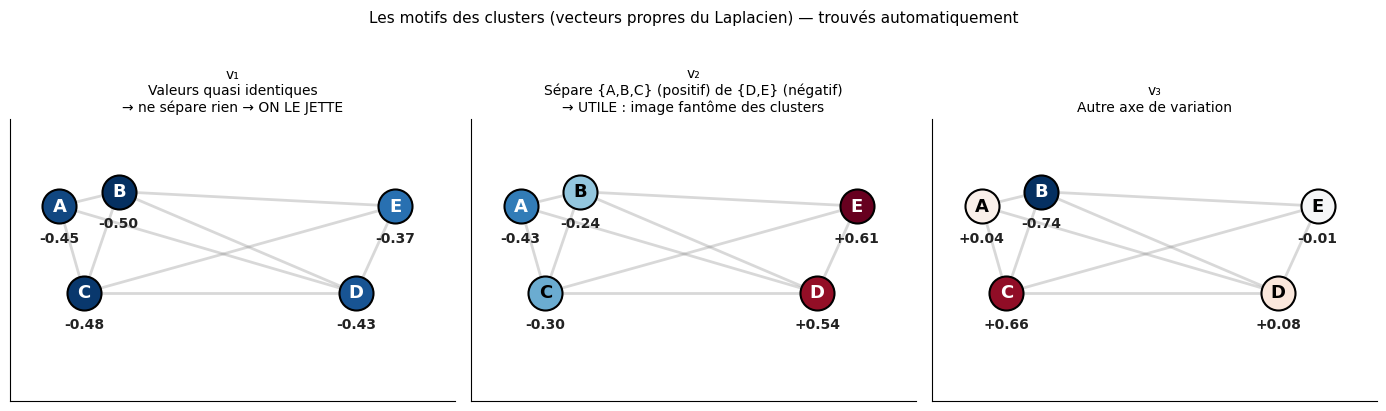

In [9]:
# Figure F4 : les 3 premiers vecteurs propres
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, (v, name, desc) in enumerate([
    (v1, 'v₁', 'Valeurs quasi identiques\n→ ne sépare rien → ON LE JETTE'),
    (v2, 'v₂', 'Sépare {A,B,C} (positif) de {D,E} (négatif)\n→ UTILE : image fantôme des clusters'),
    (v3, 'v₃', 'Autre axe de variation'),
]):
    ax = axes[ax_idx]
    rng_ = max(abs(v.min()), abs(v.max()))
    for i in range(5):
        for j in range(i+1, 5):
            if S[i, j] > 0:
                ax.plot([pts5_xy[i,0], pts5_xy[j,0]], [pts5_xy[i,1], pts5_xy[j,1]],
                        color='gray', alpha=0.3, linewidth=2, zorder=1)
    for i, (p, lab) in enumerate(zip(pts5_xy, labels5)):
        t_col = 0.5 + v[i] / (2*rng_) if rng_ > 0 else 0.5
        col = plt.cm.RdBu_r(t_col)
        ax.scatter(*p, s=600, c=[col], edgecolor='black', linewidth=1.5, zorder=3)
        ax.annotate(lab, p, ha='center', va='center', fontsize=13, fontweight='bold',
                    color='black' if 0.25 < t_col < 0.75 else 'white', zorder=4)
        ax.annotate(f'{v[i]:+.2f}', (p[0], p[1]-0.5), ha='center', fontsize=10, color='#222', fontweight='bold')
    ax.set_xlim(0, 9); ax.set_ylim(0.3, 4.2)
    ax.set_title(f'{name}\n{desc}', fontsize=10)
    ax.grid(alpha=0.3); ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Les motifs des clusters (vecteurs propres du Laplacien) — trouvés automatiquement',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.savefig('figures/F4_eigenvectors.png', dpi=120, bbox_inches='tight'); plt.show()

### Le score SPEC

Une fois v₂ connu, on demande à chaque variable f_j : *est-ce que tu suis le même schéma que v₂ ?*

$$\text{SPEC}_j = 1 - \left(\hat{f}_j \cdot v_2\right)^2$$

où $\hat{f}_j$ est la variable normalisée. **Score bas = ressemble à v₂ = pertinente.**

In [10]:
def spec_score_on_v(f, v, d):
    '''SPEC : 1 - produit_scalaire(f_normalisée, v)².'''
    f_c = f - (f @ d) / d.sum()
    norm = np.sqrt((f_c * d * f_c).sum())
    if norm < 1e-10: return 1.0
    f_hat = f_c / norm
    proj = (f_hat * np.sqrt(d) * v).sum()
    return 1 - proj**2

SPEC_x1 = spec_score_on_v(x1_signal, v2, d)
SPEC_x2 = spec_score_on_v(x2_noise, v2, d)
print(f'SPEC(x1, v2) = {SPEC_x1:.3f} (bas = bon)')
print(f'SPEC(x2, v2) = {SPEC_x2:.3f}')

SPEC(x1, v2) = 0.034 (bas = bon)
SPEC(x2, v2) = 0.998


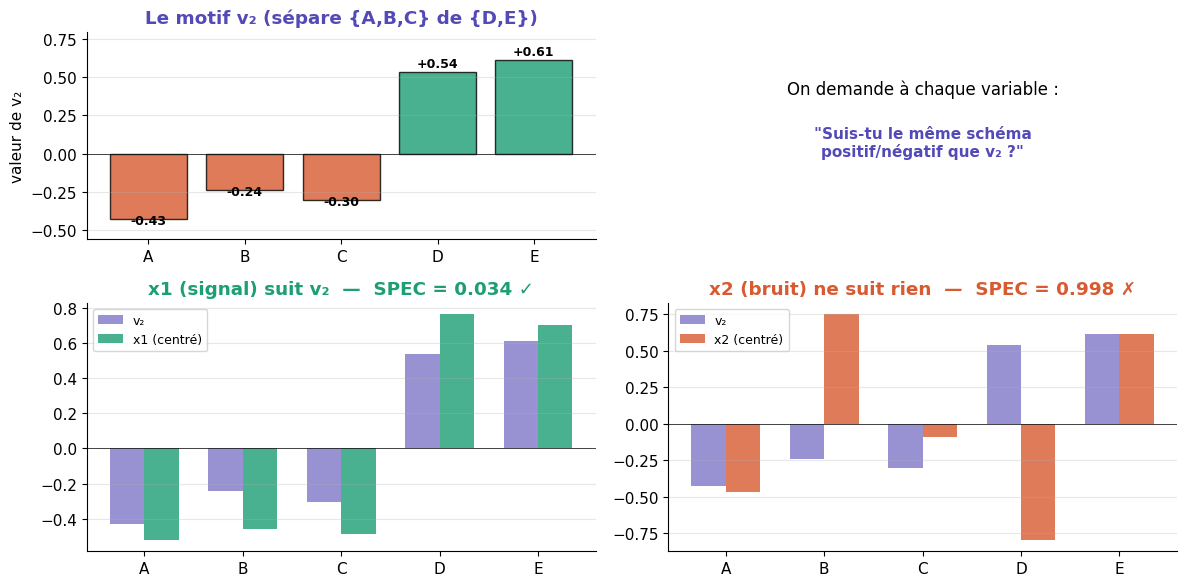

In [11]:
# Figure F5 : comparaison variable vs motif v2
fig, axes = plt.subplots(2, 2, figsize=(12, 6), gridspec_kw={'height_ratios': [1, 1.2]})

ax = axes[0, 0]
colors = [C_SIGNAL if v > 0 else C_NOISE for v in v2]
bars = ax.bar(labels5, v2, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.5)
for b, val in zip(bars, v2):
    ax.text(b.get_x()+b.get_width()/2, val+np.sign(val)*0.03, f'{val:+.2f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Le motif v₂ (sépare {A,B,C} de {D,E})', color=C_V, fontweight='bold')
ax.set_ylabel('valeur de v₂'); ax.grid(alpha=0.3, axis='y')
ax.set_ylim(v2.min()*1.3, v2.max()*1.3)

ax = axes[0, 1]; ax.axis('off')
ax.text(0.5, 0.7, 'On demande à chaque variable :', ha='center', fontsize=12)
ax.text(0.5, 0.4, '"Suis-tu le même schéma\npositif/négatif que v₂ ?"',
        ha='center', fontsize=11, fontweight='bold', color=C_V)

x = np.arange(5); width = 0.35
ax = axes[1, 0]
ax.bar(x - width/2, v2, width, color=C_V, alpha=0.6, label='v₂')
ax.bar(x + width/2, (x1_signal - x1_signal.mean())/x1_signal.std()*0.6, width, color=C_SIGNAL, alpha=0.8, label='x1 (centré)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels5)
ax.set_title(f'x1 (signal) suit v₂  —  SPEC = {SPEC_x1:.3f} ✓', color=C_SIGNAL, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

ax = axes[1, 1]
ax.bar(x - width/2, v2, width, color=C_V, alpha=0.6, label='v₂')
ax.bar(x + width/2, (x2_noise - x2_noise.mean())/x2_noise.std()*0.6, width, color=C_NOISE, alpha=0.8, label='x2 (centré)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels5)
ax.set_title(f'x2 (bruit) ne suit rien  —  SPEC = {SPEC_x2:.3f} ✗', color=C_NOISE, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.savefig('figures/F5_spec_intuition.png', dpi=120, bbox_inches='tight'); plt.show()

## A.3 MCFS — Multi-Cluster Feature Selection (Cai et al., 2010)

**Type.** Méthode *filter*. Comme SPEC + une régression LASSO.

**Question.** *Au lieu de tester chaque variable séparément contre v_l, on demande : quelles variables permettent de RECONSTRUIRE chaque motif v_l ?*

### Principe

Pour chaque motif v_l, on fait une régression LASSO :
$$\hat{w}_l = \arg\min_w \|v_l - Xw\|_2^2 + \alpha \|w\|_1$$

La pénalité ℓ₁ **élimine** (coefficient = 0 pile) les variables qui ne contribuent pas à reconstruire v_l. Les variables redondantes entre elles se partagent le poids : seule **une des deux** obtient un coefficient non nul.

**Score final** : $\text{MCFS}_j = \max_l |\hat{W}_{jl}|$ — on retient la variable si elle est utile pour **au moins un** motif.

In [12]:
# MCFS sur le jeu 300 points
def build_normalized_laplacian(X, k=5):
    W = kneighbors_graph(X, n_neighbors=k, mode='connectivity', include_self=False)
    W = (W + W.T) / 2; W = W.toarray()
    d = W.sum(axis=1)
    Dinv = np.diag(1.0 / np.sqrt(d + 1e-10))
    return np.eye(len(X)) - Dinv @ W @ Dinv

n_clusters = 3
L_norm_300 = build_normalized_laplacian(X300, k=5)
evals_300, evecs_300 = np.linalg.eigh(L_norm_300)
V_k = evecs_300[:, 1:n_clusters]  # v2, v3

# Régression LASSO pour chaque v_l
d_feat = X300.shape[1]
W_lasso = np.zeros((d_feat, n_clusters - 1))
for l in range(n_clusters - 1):
    lasso = Lasso(alpha=0.01, max_iter=10000)
    lasso.fit(X300, V_k[:, l])
    W_lasso[:, l] = lasso.coef_

MCFS_scores = np.abs(W_lasso).max(axis=1)
print(f'MCFS scores:')
for i, (name, s) in enumerate(zip(feat_names, MCFS_scores)):
    marker = ' ← signal' if i < 2 else ''
    print(f'  {name}: {s:.3f}{marker}')

MCFS scores:
  x1: 0.042 ← signal
  x2: 0.044 ← signal
  x3: 0.000
  x4: 0.000
  x5: 0.000
  x6: 0.000
  x7: 0.000
  x8: 0.000
  x9: 0.000
  x10: 0.000


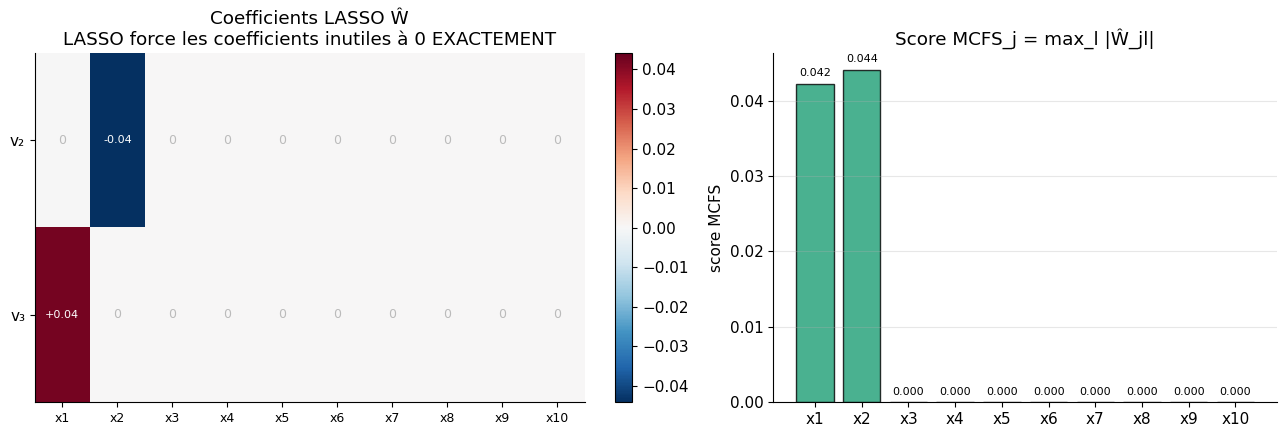

In [13]:
# Figure F6 : heatmap W + scores
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [1.2, 1]})

ax = axes[0]
vmax = np.abs(W_lasso).max()
im = ax.imshow(W_lasso.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
for l in range(W_lasso.shape[1]):
    for j in range(d_feat):
        val = W_lasso[j, l]
        if abs(val) > 0.001:
            ax.text(j, l, f'{val:+.2f}', ha='center', va='center', fontsize=8,
                    color='black' if abs(val) < vmax*0.5 else 'white')
        else:
            ax.text(j, l, '0', ha='center', va='center', fontsize=9, color='#bbb')
ax.set_xticks(range(d_feat)); ax.set_xticklabels(feat_names, fontsize=9)
ax.set_yticks(range(W_lasso.shape[1])); ax.set_yticklabels(['v₂', 'v₃'])
ax.set_title('Coefficients LASSO Ŵ\nLASSO force les coefficients inutiles à 0 EXACTEMENT')
plt.colorbar(im, ax=ax, fraction=0.04)

ax = axes[1]
colors_bar = [C_SIGNAL if i < 2 else C_NOISE for i in range(d_feat)]
bars = ax.bar(feat_names, MCFS_scores, color=colors_bar, alpha=0.8, edgecolor='black')
for b, v in zip(bars, MCFS_scores):
    ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.3f}', ha='center', fontsize=8)
ax.set_title('Score MCFS_j = max_l |Ŵ_jl|'); ax.set_ylabel('score MCFS')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.savefig('figures/F6_mcfs.png', dpi=120, bbox_inches='tight'); plt.show()

**Différence avec SPEC.** SPEC demande à chaque variable *séparément* si elle ressemble à v_l. MCFS les met *toutes ensemble* dans une régression et laisse le LASSO décider — ce qui **élimine automatiquement les redondances** : deux variables identiques se partagent le coefficient, seule une ressort.

---

# FAMILLE B — Méthodes à poids de variables

Plutôt que de calculer un score, ces méthodes **modifient K-Means** en ajoutant un poids $w_j$ à chaque variable dans le calcul de la distance :

$$\text{dist}(x_i, m_l) = \sum_j w_j \, (x_{ij} - m_{lj})^2$$

Si $w_j = 0$ ou petit → la variable est **ignorée** (ou peu prise en compte) dans le clustering.

## B.1 Sparse K-Means (Witten & Tibshirani, 2010)

**Type.** Méthode *wrapper*.

**Question.** *Quelles variables creusent le plus l'écart entre les centres des clusters ?*

### Principe

On alterne deux étapes :
1. **Avec poids fixés** → on fait K-Means → on a des clusters
2. **Avec clusters fixés** → on mesure la contribution $a_j$ = écart entre centres sur la variable j → on met à jour les poids par **soft-thresholding**

$$w_j = \frac{(a_j - \Delta)^+}{\|(a - \Delta)^+\|_2}$$

où $\Delta$ est un seuil choisi pour que $\|w\|_1 \leq s$. **Résultat : beaucoup de poids sont à 0 pile** (d'où le "sparse").

In [14]:
def sparse_kmeans(X, n_clusters, s=1.5, max_outer=30, tol=1e-4, rs=42):
    n, d = X.shape
    w = np.ones(d) / np.sqrt(d)
    w_hist = [w.copy()]
    for it in range(max_outer):
        Xw = X * np.sqrt(w)
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=rs).fit(Xw)
        labels = km.labels_
        global_mean = X.mean(axis=0)
        a = np.zeros(d)
        for c in range(n_clusters):
            mask = labels == c
            if mask.sum() == 0: continue
            a += mask.sum() * (X[mask].mean(axis=0) - global_mean)**2
        lo, hi = 0, np.abs(a).max()
        for _ in range(50):
            delta = (lo + hi) / 2
            w_tmp = np.sign(a) * np.maximum(np.abs(a) - delta, 0)
            if np.linalg.norm(w_tmp) < 1e-10:
                w_new = np.zeros_like(a); break
            w_new = w_tmp / np.linalg.norm(w_tmp)
            if w_new.sum() <= s: hi = delta
            else: lo = delta
        w_hist.append(w_new.copy())
        if np.abs(w_new - w).sum() < tol:
            w = w_new; break
        w = w_new
    return w, labels, np.array(w_hist), a

w_skm, lbl_skm, w_hist, a_skm = sparse_kmeans(X300, n_clusters=3, s=1.5)
print(f'Contributions a_j: {np.round(a_skm, 2)}')
print(f'Poids finaux:      {np.round(w_skm, 3)}')
print(f'Poids sur bruit:   {w_skm[2:].sum():.4f}  (idéalement = 0)')

Contributions a_j: [273.63 291.17   3.93   0.94   4.04   0.41   1.78   1.04   0.66   5.36]
Poids finaux:      [0.685 0.729 0.01  0.002 0.01  0.001 0.004 0.003 0.002 0.013]
Poids sur bruit:   0.0454  (idéalement = 0)


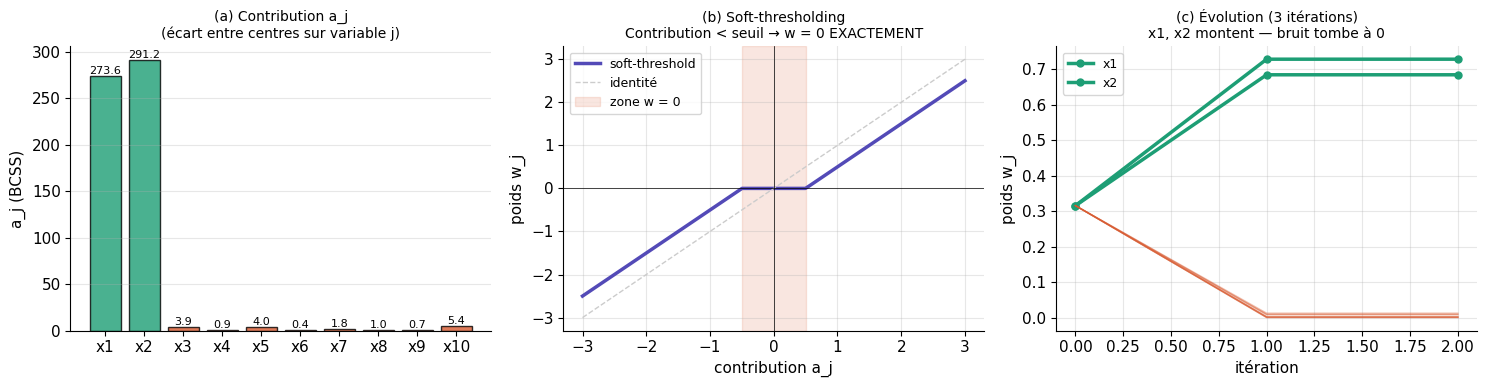

In [15]:
# Figure F7 : contributions + soft-threshold + évolution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
colors_bar = [C_SIGNAL if i < 2 else C_NOISE for i in range(10)]
bars = ax.bar(feat_names, a_skm, color=colors_bar, alpha=0.8, edgecolor='black')
for b, v in zip(bars, a_skm):
    ax.text(b.get_x()+b.get_width()/2, v+2, f'{v:.1f}', ha='center', fontsize=8)
ax.set_title('(a) Contribution a_j\n(écart entre centres sur variable j)', fontsize=10)
ax.set_ylabel('a_j (BCSS)'); ax.grid(alpha=0.3, axis='y')

ax = axes[1]
a_range = np.linspace(-3, 3, 200); delta_demo = 0.5
w_demo = np.sign(a_range) * np.maximum(np.abs(a_range) - delta_demo, 0)
ax.plot(a_range, w_demo, color=C_V, linewidth=2.5, label='soft-threshold')
ax.plot(a_range, a_range, '--', color='#ccc', linewidth=1, label='identité')
ax.axvspan(-delta_demo, delta_demo, alpha=0.15, color=C_NOISE, label='zone w = 0')
ax.axhline(0, color='black', linewidth=0.5); ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('(b) Soft-thresholding\nContribution < seuil → w = 0 EXACTEMENT', fontsize=10)
ax.set_xlabel('contribution a_j'); ax.set_ylabel('poids w_j')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.3)

ax = axes[2]
n_iter = len(w_hist)
for j in range(10):
    col = C_SIGNAL if j < 2 else C_NOISE
    alpha = 1.0 if j < 2 else 0.4
    lw = 2.5 if j < 2 else 1
    ax.plot(range(n_iter), w_hist[:, j], color=col, alpha=alpha, linewidth=lw,
            marker='o' if j < 2 else '', markersize=5, label=f'x{j+1}' if j < 2 else None)
ax.set_title(f'(c) Évolution ({n_iter} itérations)\nx1, x2 montent — bruit tombe à 0', fontsize=10)
ax.set_xlabel('itération'); ax.set_ylabel('poids w_j')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('figures/F7_sparse_kmeans.png', dpi=120, bbox_inches='tight'); plt.show()

## B.2 FWKM — Feature Weighted K-Means (Modha & Spangler, 2003)

**Type.** Méthode *embedded*.

**Question.** *Inverse de Sparse K-Means* : au lieu de regarder les écarts entre centres, on regarde la **dispersion à l'intérieur** de chaque cluster.

- Points serrés dans le cluster → variable pertinente → **gros poids**
- Points éparpillés → variable bruit → **petit poids** (mais jamais 0)

### Formule

$$w_j = \frac{1/D_j}{\sum_{j'} 1/D_{j'}}\quad\text{où}\quad D_j = \sum_{c}\sum_{i \in C_c}(x_{ij} - m_{cj})^2$$

- $D_j$ = dispersion intra-cluster totale sur la variable j
- Poids **inversement proportionnel** à la dispersion
- **Jamais nul** : contrairement à Sparse K-Means, FWKM assouplit le bruit au lieu de le supprimer
- **Avantage** : s'étend naturellement au Fuzzy C-Means en remplaçant $r_{il}$ par $\mu_{il}^m$

In [16]:
def fwkm(X, n_clusters, max_iter=20, rs=42):
    n, d = X.shape
    w = np.ones(d) / d
    for it in range(max_iter):
        Xw = X * np.sqrt(w)
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=rs).fit(Xw)
        labels = km.labels_
        D_j = np.zeros(d)
        for c in range(n_clusters):
            mask = labels == c
            if mask.sum() == 0: continue
            D_j += ((X[mask] - X[mask].mean(axis=0))**2).sum(axis=0)
        inv_D = 1.0 / (D_j + 1e-10)
        w_new = inv_D / inv_D.sum()
        if np.abs(w_new - w).max() < 1e-5:
            break
        w = w_new
    return w, labels, D_j

w_fw, lbl_fw, D_j_fw = fwkm(X300, n_clusters=3)
print(f'Dispersion intra-cluster par variable:')
for i, (name, d_) in enumerate(zip(feat_names, D_j_fw)):
    marker = ' ← signal' if i < 2 else ''
    print(f'  {name}: D = {d_:.1f}{marker}')
print(f'\nPoids FWKM: {np.round(w_fw, 3)}')

Dispersion intra-cluster par variable:
  x1: D = 26.4 ← signal
  x2: D = 8.8 ← signal
  x3: D = 296.1
  x4: D = 299.1
  x5: D = 296.0
  x6: D = 299.6
  x7: D = 298.2
  x8: D = 299.0
  x9: D = 299.3
  x10: D = 294.6

Poids FWKM: [0.213 0.636 0.019 0.019 0.019 0.019 0.019 0.019 0.019 0.019]


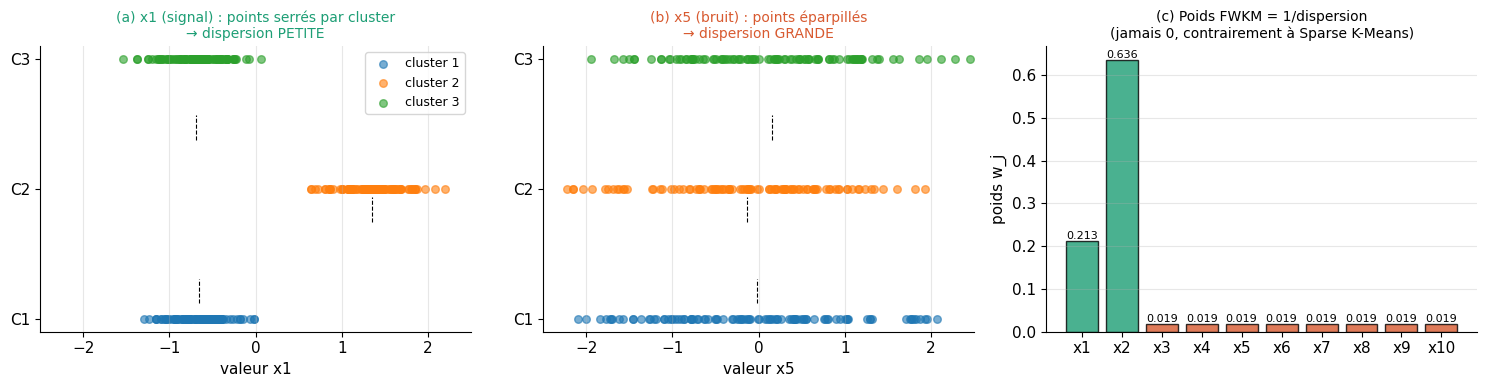

In [17]:
# Figure F8 : dispersion intra-cluster sur signal vs bruit + poids
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.set_title('(a) x1 (signal) : points serrés par cluster\n→ dispersion PETITE', fontsize=10, color=C_SIGNAL)
for c in range(3):
    mask = y300 == c
    y_level = c + 0.5
    ax.scatter(X300[mask, 0], np.full(mask.sum(), y_level), s=30, alpha=0.6, label=f'cluster {c+1}')
    centre_c = X300[mask, 0].mean()
    ax.axvline(centre_c, ymin=(y_level-0.15)/3.5, ymax=(y_level+0.15)/3.5, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('valeur x1'); ax.set_yticks([0.5, 1.5, 2.5]); ax.set_yticklabels(['C1','C2','C3'])
ax.grid(alpha=0.3, axis='x'); ax.legend(fontsize=9, loc='upper right'); ax.set_xlim(-2.5, 2.5)

ax = axes[1]
ax.set_title('(b) x5 (bruit) : points éparpillés\n→ dispersion GRANDE', fontsize=10, color=C_NOISE)
for c in range(3):
    mask = y300 == c
    y_level = c + 0.5
    ax.scatter(X300[mask, 4], np.full(mask.sum(), y_level), s=30, alpha=0.6)
    centre_c = X300[mask, 4].mean()
    ax.axvline(centre_c, ymin=(y_level-0.15)/3.5, ymax=(y_level+0.15)/3.5, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('valeur x5'); ax.set_yticks([0.5, 1.5, 2.5]); ax.set_yticklabels(['C1','C2','C3'])
ax.grid(alpha=0.3, axis='x'); ax.set_xlim(-2.5, 2.5)

ax = axes[2]
colors_bar = [C_SIGNAL if i < 2 else C_NOISE for i in range(10)]
bars = ax.bar(feat_names, w_fw, color=colors_bar, alpha=0.8, edgecolor='black')
for b, v in zip(bars, w_fw):
    ax.text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=8)
ax.set_title('(c) Poids FWKM = 1/dispersion\n(jamais 0, contrairement à Sparse K-Means)', fontsize=10)
ax.set_ylabel('poids w_j'); ax.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.savefig('figures/F8_fwkm.png', dpi=120, bbox_inches='tight'); plt.show()

---

# Synthèse — Les 5 méthodes côte à côte

In [18]:
# Laplacian Score et SPEC sur 300 points
def laplacian_score_matrix(X, k=5):
    W = kneighbors_graph(X, n_neighbors=k, mode='distance', include_self=False)
    W = W.toarray()
    t = np.median(W[W>0])**2
    W[W>0] = np.exp(-W[W>0]**2 / t)
    W = (W + W.T) / 2
    d = W.sum(axis=1); D_m = np.diag(d); L = D_m - W
    scores = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        f = X[:, j].copy()
        ft = f - (f @ d) / d.sum()
        num = ft @ L @ ft; den = ft @ D_m @ ft
        scores[j] = num/den if den > 0 else np.inf
    return scores

def spec_scores_300(X, k=5, n_v=2):
    W = kneighbors_graph(X, n_neighbors=k, mode='connectivity', include_self=False)
    W = (W + W.T) / 2; W = W.toarray()
    d = W.sum(axis=1); Dinv = np.diag(1.0/np.sqrt(d+1e-10))
    L = np.eye(len(X)) - Dinv @ W @ Dinv
    evals, evecs = np.linalg.eigh(L); V = evecs[:, 1:n_v+1]
    scores = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        f = X[:, j].copy(); f_c = f - f.mean()
        norm = np.linalg.norm(f_c)
        if norm < 1e-10: scores[j] = 1.0; continue
        f_hat = f_c / norm
        scores[j] = 1 - max(abs(f_hat @ V[:, l]) for l in range(n_v))**2
    return scores

LS_300 = laplacian_score_matrix(X300, k=5)
SPEC_300 = spec_scores_300(X300, k=5, n_v=2)

# Tableau récapitulatif
print(f"{'Méthode':<18} {'x1':>8} {'x2':>8} {'bruit_moy':>10}")
print("-" * 46)
for name, scores, sense in [
    ('Laplacian Score', LS_300, 'bas'),
    ('SPEC',            SPEC_300, 'bas'),
    ('Sparse K-Means',  w_skm, 'haut'),
    ('MCFS',            MCFS_scores, 'haut'),
    ('FWKM',            w_fw, 'haut'),
]:
    bruit_moy = scores[2:].mean()
    print(f'{name:<18} {scores[0]:>8.3f} {scores[1]:>8.3f} {bruit_moy:>10.4f}')

Méthode                  x1       x2  bruit_moy
----------------------------------------------
Laplacian Score       0.097    0.048     0.3558
SPEC                  0.182    0.122     0.9901
Sparse K-Means        0.685    0.729     0.0057
MCFS                  0.042    0.044     0.0000
FWKM                  0.213    0.636     0.0189


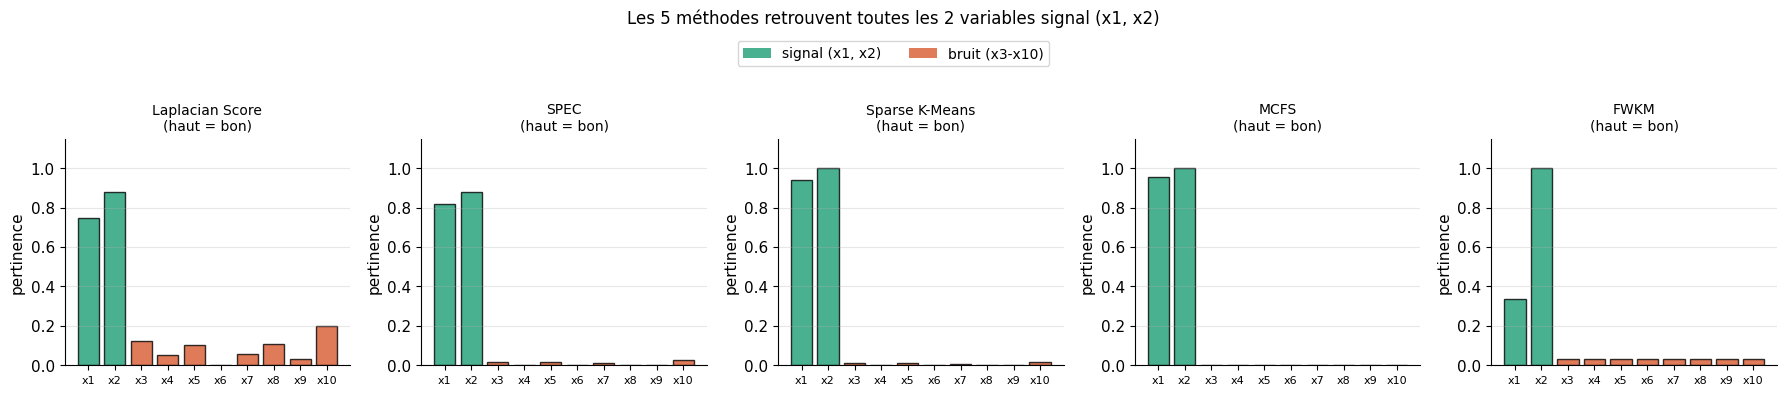

In [19]:
# Figure récap 5 méthodes
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
scores_dict = [
    ('Laplacian Score', LS_300,   'bas'),
    ('SPEC',            SPEC_300, 'bas'),
    ('Sparse K-Means',  w_skm,    'haut'),
    ('MCFS',            MCFS_scores, 'haut'),
    ('FWKM',            w_fw,     'haut'),
]

for ax, (name, scores, sense) in zip(axes, scores_dict):
    s_norm = scores / (scores.max() if scores.max() > 0 else 1)
    s_show = 1 - s_norm if sense == 'bas' else s_norm
    colors_bar = [C_SIGNAL if i < 2 else C_NOISE for i in range(10)]
    ax.bar(feat_names, s_show, color=colors_bar, alpha=0.8, edgecolor='black')
    ax.set_title(f'{name}\n(haut = bon)', fontsize=10)
    ax.set_ylabel('pertinence'); ax.grid(alpha=0.3, axis='y')
    ax.set_ylim(0, 1.15); ax.tick_params(axis='x', labelsize=8)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor=C_SIGNAL, alpha=0.8, label='signal (x1, x2)'),
    Patch(facecolor=C_NOISE, alpha=0.8, label='bruit (x3-x10)')
], loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=10)

plt.suptitle('Les 5 méthodes retrouvent toutes les 2 variables signal (x1, x2)',
             fontsize=12, y=1.12)
plt.tight_layout(); plt.savefig('figures/F9_recap5.png', dpi=120, bbox_inches='tight'); plt.show()

## Tableau récapitulatif

| Méthode | Famille | Interprétation | Score |
|---|---|---|---|
| **Laplacian Score** | filter spectrale | variable lisse sur le graphe | bas = bon |
| **SPEC** | filter spectrale | variable alignée avec motif clusters | bas = bon |
| **MCFS** | filter spectrale + LASSO | variable reconstruit les motifs (sans redondance) | haut = bon |
| **Sparse K-Means** | wrapper | centres des clusters éloignés sur cette variable | haut = bon (0 = jetée) |
| **FWKM** | embedded | points serrés dans chaque cluster | haut = bon (jamais 0) |

## Orientation du projet

- **Laplacian Score et SPEC** sont les plus simples — bonne baseline spectrale
- **MCFS** ajoute la gestion des redondances (LASSO)
- **Sparse K-Means** élimine drastiquement (poids = 0)
- **FWKM** est la seule directement compatible avec le Fuzzy C-Means (FCM) du projet CEA — c'est celle qui s'étendra naturellement au système de Sugeno.